# Import Libraries

In [170]:
import pandas as pd
import numpy as np
import boto3
import s3fs
import matplotlib.pyplot as plt
import seaborn as sns
# Weather data library
from meteostat import Stations, Daily
from datetime import datetime
from pyathena import connect
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

# Connect SageMaker to S3

In [171]:
#Create S3 client using boto3
#This allows the notebook to communicate with S3
s3 = boto3.client('s3')

#Define your S3 bucket name where your datasets are stored
bucket = "vegetation-risk-ml"

#list files inside bucket
response = s3.list_objects_v2(Bucket=bucket)

#Print the names of the files in the bucket
for obj in response['Contents']:
    print(obj['Key'])

athena-results/
processed/
processed/fire/fire_cleaned.csv
processed/forest/forest_cleaned.csv
processed/weather/weather_cleaned.csv
raw/
raw/fire/
raw/fire/California_Historic_Fire_data.csv
raw/forest/
raw/forest/CA_PLOT.csv
raw/forest/CA_SUBPLOT.csv
raw/forest/CA_TREE.csv
raw/forest/CA_TREE_REGIONAL_BIOMASS.csv
raw/forest/combined_forest_data.csv
raw/weather/
raw/weather/california_weather_data.csv


# **DATA PREPARATION**

**Define s3 path**

In [172]:
#Define S3 fi
forest_path  = "s3://vegetation-risk-ml/raw/forest/combined_forest_data.csv"
fire_path    = "s3://vegetation-risk-ml/raw/fire/California_Historic_Fire_data.csv"
weather_path = "s3://vegetation-risk-ml/raw/weather/california_weather_data.csv"

**Load datasets**

In [173]:
combined_forest = pd.read_csv(forest_path, low_memory=False)
print("Forest dataset shape :", combined_forest.shape)
fire = pd.read_csv(fire_path, low_memory=False)
print("Fire dataset shape :", fire.shape)
weather = pd.read_csv(weather_path, low_memory=False)
print("Weather dataset shape :", weather.shape)

print("Datasets loaded successfully")

Forest dataset shape : (1687167, 14)
Fire dataset shape : (3372, 23)
Weather dataset shape : (309116, 10)
Datasets loaded successfully


# DATA CLEANING AND PREPROCESSING

### Forest dataset cleaning

We will handle missing values and drop the unnecessary columns so that the dataset represents only relevent columns which directly affects trimming prioritization.This stage will prepare our dataset for integration.

Here only variables that influence vegetation density and wildfire potential are retained.

**Drop unnecessary columns**

 We drop plt_cn,spsd to avoid noise in the data and reduce memory usage.From exploration,we know that REGIONAL_DRYBIOT and REGIONAL_DRYBIOM are highly correlated so we keep only one of them.

In [174]:
#select most relevent column 
combined_forest=combined_forest[["DIA", "HT", "SLOPE", "REGIONAL_DRYBIOT","LAT", "LON","COUNTYCD"]]  #tree size,height,terrain,direction,biomass

#check the shape of the dataset
combined_forest.shape

(1687167, 7)

**Remove Duplicates**

In [175]:
#remove duplicates
combined_forest = combined_forest.drop_duplicates()
# Verify
print("Duplicates remaining:", combined_forest.duplicated().sum())

Duplicates remaining: 0


**Handle missing valus**

To handle missing values, median is used because biomass is skewed and avoids distortion from outliers.

In [176]:
#fill missing values for biomass
combined_forest = combined_forest.dropna(subset=["LAT", "LON"])
combined_forest["REGIONAL_DRYBIOT"] = combined_forest["REGIONAL_DRYBIOT"].fillna(combined_forest["REGIONAL_DRYBIOT"].median())
combined_forest["SLOPE"] = combined_forest["SLOPE"].fillna(combined_forest["SLOPE"].median())
combined_forest["DIA"] = combined_forest["DIA"].fillna(combined_forest["DIA"].median()) 
combined_forest["HT"] = combined_forest["HT"].fillna(combined_forest["HT"].median())                                                     

# Verify
print("Missing values:\n", combined_forest.isnull().sum())

Missing values:
 DIA                 0
HT                  0
SLOPE               0
REGIONAL_DRYBIOT    0
LAT                 0
LON                 0
COUNTYCD            0
dtype: int64


**Handle outlier**

In [177]:
#handle unrealistic value of tree diameter and height
combined_forest = combined_forest[(combined_forest["DIA"] > 0) & (combined_forest["HT"] > 0)]

In [178]:
#Verify the resulting dataset
combined_forest.head()

,DIA,HT,SLOPE,REGIONAL_DRYBIOT,LAT,LON,COUNTYCD
0,3.9,43.0,50.0,404.669221,41.478172,-123.946777,15
1,3.9,43.0,60.0,404.669221,41.478172,-123.946777,15
2,3.9,43.0,40.0,404.669221,41.478172,-123.946777,15
3,24.1,95.0,50.0,404.669221,41.478172,-123.946777,15
4,24.1,95.0,60.0,404.669221,41.478172,-123.946777,15


### Fire dataset cleaning

Here we will keep valid geographic coordinates and meaningful fire size measurements only.

**Select Relevent Columns**

In [179]:
#select relevant features only
fire=fire[["incident_acres_burned", "incident_longitude", "incident_latitude", "incident_date_created","incident_county"]]

In [180]:
#remove fires with invalid coordinates (outside California)
fire = fire[(fire["incident_latitude"].between(32, 42)) &(fire["incident_longitude"].between(-124, -114))]

#Remove fires with missing coordinates
fire = fire.dropna(subset=["incident_latitude", "incident_longitude"])

#Remove fires with zero size
fire = fire[fire["incident_acres_burned"] > 0]

#Convert datecolumn to datetime and remove timezone
fire["incident_date_created"] = pd.to_datetime(fire["incident_date_created"], errors="coerce").dt.date

# Remove missing county
fire = fire.dropna(subset=["incident_county", "incident_date_created"])

# Reset index
fire = fire.reset_index(drop=True)

#display results
print("Cleaned fire dataset shape:", fire.shape)


Cleaned fire dataset shape: (3253, 5)


In [181]:
#check for any remaining missing value
print(fire.isnull().sum())
fire.head()

incident_acres_burned    0
incident_longitude       0
incident_latitude        0
incident_date_created    0
incident_county          0
dtype: int64


,incident_acres_burned,incident_longitude,incident_latitude,incident_date_created,incident_county
0,37.0,-122.309000,40.774000,2017-10-31,Shasta
1,407.0,-118.016510,36.602575,2013-02-24,Inyo
2,30.0,-116.941311,34.288877,2013-04-20,San Bernardino
3,274.0,-119.635004,37.116295,2013-04-30,Madera
4,6896.0,-121.595555,40.190062,2013-05-01,Tehama


#### Weather dataset cleaning

We will select temperature ,precipitation and wind speed that influence vegetation growth and fire risk. Here missing values are imputed to ensure consistent weather observations.

In [182]:

# Fill missing rainfall
weather["prcp"] = weather["prcp"].fillna(0)

# Fill wind speed
weather["wspd"] = weather["wspd"].fillna(weather["wspd"].median())

# Remove unrealistic temperatures
weather = weather[(weather["tavg"] > -40) & (weather["tavg"] < 60)]

# Fill missing average temperature
weather["tavg"] = weather["tavg"].fillna((weather["tmin"] + weather["tmax"])/2)

# We can drop tmax and tmin as we have tavg, and they are highly correlated
#also we will drop pressure because of week correlation
weather = weather[['time','tavg', 'prcp', 'wspd', 'station', 'lat', 'lon']]

In [183]:
#Verify the resulting dataset
print("Cleaned weather dataset shape:", weather.shape)
#check for any remaining missing values
print("Missing values in each column:")
print(weather.isnull().sum())
print("First few rows of the cleaned dataset:")
weather.head()

Cleaned weather dataset shape: (301803, 7)
Missing values in each column:
time       0
tavg       0
prcp       0
wspd       0
station    0
lat        0
lon        0
dtype: int64
First few rows of the cleaned dataset:


,time,tavg,prcp,wspd,station,lat,lon
0,2020-11-05,13.6,0.0,9.4,69007,36.6815,-121.7617
1,2020-11-06,12.0,0.0,9.4,69007,36.6815,-121.7617
2,2020-11-07,10.0,0.0,9.4,69007,36.6815,-121.7617
3,2020-11-08,9.0,0.0,9.4,69007,36.6815,-121.7617
4,2020-11-09,5.7,0.0,9.4,69007,36.6815,-121.7617


#### **Save the cleaned dataset to S3**

The cleaned datasets are then store back in S3 in separete folder processed/ for future analysis.

In [184]:
combined_forest.to_csv("s3://vegetation-risk-ml/processed/forest/forest_cleaned.csv",index=False)

fire.to_csv("s3://vegetation-risk-ml/processed/fire/fire_cleaned.csv",index=False)

weather.to_csv("s3://vegetation-risk-ml/processed/weather/weather_cleaned.csv",index=False)

print("Cleaned datasets saved successfully in S3")

Cleaned datasets saved successfully in S3


Next,to merge all three cleaned datasets, we are using Athena.

Athena is used to perform  data merging of all three cleaned datasets and aggregation directly on S3 without loading large datasets into memory.This resolves the high memory usage and slow processing.The final unified feature table will be used for model training and dashboard visualization.

# Connect SageMaker to Athena

In [185]:
#Create folfer in S3 to save athena results
s3 = boto3.client("s3")

s3.put_object(Bucket="vegetation-risk-ml",Key="athena-results/")
print("athena-results folder created in S3")

athena-results folder created in S3


In [186]:
#verify the athena results folder is created
response = s3.list_objects_v2(Bucket="vegetation-risk-ml",Prefix="athena-results/")
print("Folder exists:", "athena-results/" in [obj["Key"] for obj in response.get("Contents", [])])

Folder exists: True


In [187]:

#Query results are stored in s3 in this directory
s3_staging_dir = "s3://vegetation-risk-ml/athena-results/"

# Athena connection
conn = connect(s3_staging_dir=s3_staging_dir,region_name="us-east-1")

print("Connected to Athena")

Connected to Athena


# Create Table for Forest Dataset

In [188]:
#drop old tables if exist
drop_query = """
DROP TABLE IF EXISTS vegetation_ml.forest_cleaned
"""
pd.read_sql(drop_query, conn)
print("Old table dropped if any")

Old table dropped if any


In [189]:
#create forest table
forest_query = """
CREATE EXTERNAL TABLE IF NOT EXISTS vegetation_ml.forest_cleaned (
    DIA DOUBLE,
    HT DOUBLE,
    SLOPE DOUBLE,
    REGIONAL_DRYBIOT DOUBLE,
    lat DOUBLE,
    lon DOUBLE,
    COUNTYCD INT
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
LOCATION 's3://vegetation-risk-ml/processed/forest/'
TBLPROPERTIES ("skip.header.line.count"="1","use.null.for.invalid.data"="true");
"""

pd.read_sql(forest_query, conn)
print("Forest table created successfully")

Forest table created successfully


# Create Table for Weather Dataset

In [190]:
#drop if table already exists
drop_query = """
DROP TABLE IF EXISTS vegetation_ml.weather_cleaned
"""
pd.read_sql(drop_query, conn)
print("Old table dropped")

Old table dropped


In [191]:
weather_query = """
CREATE EXTERNAL TABLE IF NOT EXISTS vegetation_ml.weather_cleaned (
    time STRING,
    tavg DOUBLE,
    prcp DOUBLE,
    wspd DOUBLE,
    station STRING,
    lat DOUBLE,
    lon DOUBLE
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
LOCATION 's3://vegetation-risk-ml/processed/weather/'
TBLPROPERTIES ("skip.header.line.count"="1","use.null.for.invalid.data"="true");
"""
pd.read_sql(weather_query, conn)
print("Weather table created successfully")


Weather table created successfully


# Create Table for Fire Dataset

In [192]:
#drop if table exists
drop_query = """
DROP TABLE IF EXISTS vegetation_ml.fire_cleaned
"""
pd.read_sql(drop_query, conn)

""


In [193]:
fire_query = """
CREATE EXTERNAL TABLE IF NOT EXISTS vegetation_ml.fire_cleaned (
    incident_acres_burned DOUBLE,
    lon DOUBLE,
    lat DOUBLE,
    incident_date_created STRING,
    incident_county STRING
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
LOCATION 's3://vegetation-risk-ml/processed/fire/'
TBLPROPERTIES ("skip.header.line.count"="1","use.null.for.invalid.data"="true");
"""
pd.read_sql(fire_query, conn)
print("Fire table created successfully")

Fire table created successfully


**Verify tables**

In [194]:

# Check if tables exist and data is accessible
for table in ["forest_cleaned", "weather_cleaned", "fire_cleaned"]:
    query = f"SELECT * FROM vegetation_ml.{table} LIMIT 5"
    df = pd.read_sql(query, conn)
    print(f"Sample data from {table}:")
    print(df.head())
    print("\n")

Sample data from forest_cleaned:
    dia    ht  slope  regional_drybiot        lat         lon  countycd
0   3.9  43.0   50.0        404.669221  41.478172 -123.946777        15
1   3.9  43.0   60.0        404.669221  41.478172 -123.946777        15
2   3.9  43.0   40.0        404.669221  41.478172 -123.946777        15
3  24.1  95.0   50.0        404.669221  41.478172 -123.946777        15
4  24.1  95.0   60.0        404.669221  41.478172 -123.946777        15


Sample data from weather_cleaned:
         time  tavg  prcp  wspd station      lat       lon
0  2020-11-05  13.6   0.0   9.4   69007  36.6815 -121.7617
1  2020-11-06  12.0   0.0   9.4   69007  36.6815 -121.7617
2  2020-11-07  10.0   0.0   9.4   69007  36.6815 -121.7617
3  2020-11-08   9.0   0.0   9.4   69007  36.6815 -121.7617
4  2020-11-09   5.7   0.0   9.4   69007  36.6815 -121.7617


Sample data from fire_cleaned:
   incident_acres_burned         lon        lat incident_date_created  \
0                   37.0 -122.309000  4

# Create Unified Feature table in Athena

Now we create the final Feature table by merging all three tables. This final table becomes the single source of truth for modelling and dashboard analysis.

The three tables are then merged in Athena by first aggregating fire incidents to the county level and calculating county centroids. Weather stations were then joined to these centroids using spatial proximity join, and each forest tree was matched to its nearest county centroid. This creates a unified dataset where every tree record has associated county-level fire statistics and weather data from nearby stations.

In [235]:
drop_query = "DROP TABLE IF EXISTS vegetation_ml.vegetation_risk_dataset"
pd.read_sql(drop_query, conn)
print("Old vegetation_risk_dataset table dropped if exists")

Old vegetation_risk_dataset table dropped if exists


The three datasets are merged in Athena using latitude and longitude as the geographic key, with the forest table as the anchor. Fire incidents are aggregated to county level and each forest plot is matched to the nearest county centroid within 0.5 degrees, while weather data is aggregated by station and matched within 1.0 degree. In both joins, ROW_NUMBER() ordered by Euclidean distance ensures every forest plot retains only its single closest fire county and nearest weather station.Thus resulting  a unified table where every forest record carries its own local fire history and weather conditions.

In [236]:
create_query = """
CREATE TABLE vegetation_ml.vegetation_risk_dataset
WITH (
    format='PARQUET',
    external_location='s3://vegetation-risk-ml/final/'
) AS

WITH county_fire AS (
    SELECT
        TRIM(SPLIT_PART(incident_county, ',', 1)) AS incident_county,
        COUNT(*) AS fire_count,
        MAX(incident_acres_burned) AS max_fire_size,
        AVG(incident_acres_burned) AS avg_fire_size,
        AVG(lat) AS fire_lat,   
        AVG(lon) AS fire_lon,   
        YEAR(CURRENT_DATE) - YEAR(MAX(DATE_PARSE(incident_date_created, '%Y-%m-%d'))) AS years_since_fire,
        MONTH(MAX(DATE_PARSE(incident_date_created, '%Y-%m-%d'))) AS fire_month
    FROM vegetation_ml.fire_cleaned
    WHERE incident_county IS NOT NULL
      AND incident_date_created IS NOT NULL
      AND incident_acres_burned > 0
      AND lat BETWEEN 32 AND 42
      AND lon BETWEEN -124 AND -114
    GROUP BY TRIM(SPLIT_PART(incident_county, ',', 1))
),

weather_station AS (
    SELECT
        ROUND(lat, 1) AS lat_bucket,
        ROUND(lon, 1) AS lon_bucket,
        AVG(tavg) AS avg_temp,
        AVG(prcp) AS avg_rain,
        AVG(wspd) AS avg_wind
    FROM vegetation_ml.weather_cleaned
    WHERE tavg IS NOT NULL
      AND prcp IS NOT NULL
      AND wspd IS NOT NULL
      AND lat BETWEEN 32 AND 42
      AND lon BETWEEN -124 AND -114
    GROUP BY ROUND(lat, 1), ROUND(lon, 1)
),

forest_clean AS (
    SELECT *
    FROM vegetation_ml.forest_cleaned
    WHERE lat BETWEEN 32.0 AND 42.0
      AND lon BETWEEN -124.5 AND -114.0
      AND DIA > 0
      AND HT > 0
      AND REGIONAL_DRYBIOT > 0
      AND COUNTYCD IS NOT NULL
),

fire_match AS (
    SELECT
        f.*,
        cf.incident_county,
        cf.fire_count,
        cf.max_fire_size,
        cf.avg_fire_size,
        cf.years_since_fire,
        cf.fire_month,

        SQRT(
            POWER((f.lat - cf.fire_lat) * 111, 2) +
            POWER((f.lon - cf.fire_lon) * 111 * COS(RADIANS((f.lat + cf.fire_lat)/2)), 2)
        ) AS fire_distance_km,

        ROW_NUMBER() OVER (
            PARTITION BY f.lat, f.lon, f.DIA, f.HT
            ORDER BY
                (f.lat - cf.fire_lat)*(f.lat - cf.fire_lat) +
                (f.lon - cf.fire_lon)*(f.lon - cf.fire_lon)
        ) AS fire_rn

    FROM forest_clean f
    LEFT JOIN county_fire cf
        ON ABS(f.lat - cf.fire_lat) < 1.0
       AND ABS(f.lon - cf.fire_lon) < 1.0
)

SELECT
    fm.DIA,
    fm.HT,
    fm.SLOPE,
    fm.REGIONAL_DRYBIOT,
    fm.lat,
    fm.lon,
    fm.COUNTYCD,

    COALESCE(fm.incident_county, 'No_Fire_Region') AS incident_county,
    COALESCE(fm.fire_count, 0)              AS fire_count,
    COALESCE(fm.max_fire_size, 0.0)         AS max_fire_size,
    COALESCE(fm.avg_fire_size, 0.0)         AS avg_fire_size,
    COALESCE(fm.years_since_fire, 99)       AS years_since_fire,
    COALESCE(fm.fire_month, 0)              AS fire_month,
    COALESCE(fm.fire_distance_km, 999)      AS fire_distance_km,

    COALESCE(ws.avg_temp, 14.2)             AS avg_temp,
    COALESCE(ws.avg_rain, 1.8)              AS avg_rain,
    COALESCE(ws.avg_wind, 6.3)              AS avg_wind

FROM fire_match fm
LEFT JOIN weather_station ws
    ON ROUND(fm.lat, 1) = ws.lat_bucket
   AND ROUND(fm.lon, 1) = ws.lon_bucket

WHERE fm.fire_rn = 1
;
"""

pd.read_sql(create_query, conn)
print("Unified feature table created successfully")

Unified feature table created successfully


In [237]:
county_query = """
SELECT DISTINCT incident_county, fire_count, years_since_fire, fire_month
FROM vegetation_ml.vegetation_risk_dataset
ORDER BY incident_county LIMIT 20
"""
print(pd.read_sql(county_query, conn))

   incident_county  fire_count  years_since_fire  fire_month
0          Alameda          59                 1          10
1           Alpine           2                 5           7
2           Amador          26                 1          12
3            Butte         102                 1           9
4        Calaveras          44                 1           9
5           Colusa          14                 1           6
6     Contra Costa          49                 1           7
7        Del Norte           3                 3           8
8        El Dorado          57                 1           9
9           Fresno         180                 1           9
10           Glenn          15                 1           7
11        Humboldt          36                 1           9
12        Imperial           4                 1          11
13            Inyo          21                 1           8
14            Kern         170                 1           9
15           Kings      

In [238]:
weather_check = """
SELECT COUNT(*) AS total_stations,MIN(lat) AS min_lat, MAX(lat) AS max_lat,MIN(lon) AS min_lon, MAX(lon) AS max_lon
FROM vegetation_ml.weather_cleaned
"""
print(pd.read_sql(weather_check, conn))

   total_stations  min_lat  max_lat   min_lon   max_lon
0          301803  32.6167  41.7802 -124.2365 -114.6233


In [239]:
fire_check = """
SELECT DISTINCT incident_county
FROM vegetation_ml.fire_cleaned
ORDER BY incident_county
LIMIT 20
"""
print(pd.read_sql(fire_check, conn))


                                 incident_county
0                                        Alameda
1                           Alameda, San Joaquin
2                                         Alpine
3                                         Amador
4                              Amador, Calaveras
5                              Amador, El Dorado
6                                          Butte
7          Butte, Plumas, Shasta, Lassen, Tehama
8                                  Butte, Tehama
9                                      Calaveras
10  Calaveras, San Joaquin, Stanislaus, Tuolumne
11                                        Colusa
12                                  Colusa, Lake
13                       Colusa, Lake, Mendocino
14                Colusa, Mendocino, Glenn, Lake
15                                  Contra Costa
16                                     Del Norte
17                                     El Dorado
18                     El Dorado, Alpine, Amador
19                  

In [240]:
query = "SELECT * FROM vegetation_ml.vegetation_risk_dataset LIMIT 5"
vegetation_risk_dataset = pd.read_sql(query, conn)

vegetation_risk_dataset.head()

,dia,ht,slope,regional_drybiot,lat,lon,countycd,incident_county,fire_count,max_fire_size,avg_fire_size,years_since_fire,fire_month,fire_distance_km,avg_temp,avg_rain,avg_wind
0,3.9,43.0,50.0,404.669221,41.478172,-123.946777,15,Humboldt,36,50198.0,2618.888889,1,9,79.438034,14.2,1.8,6.3
1,10.5,52.0,50.0,404.669221,41.478172,-123.946777,15,Humboldt,36,50198.0,2618.888889,1,9,79.438034,14.2,1.8,6.3
2,20.4,103.0,50.0,404.669221,41.478172,-123.946777,15,Humboldt,36,50198.0,2618.888889,1,9,79.438034,14.2,1.8,6.3
3,6.2,46.0,50.0,404.669221,41.478172,-123.946777,15,Humboldt,36,50198.0,2618.888889,1,9,79.438034,14.2,1.8,6.3
4,2.8,30.0,50.0,404.669221,41.478172,-123.946777,15,Humboldt,36,50198.0,2618.888889,1,9,79.438034,14.2,1.8,6.3


**Load Final Feature Table from S3 into SageMaker**

The unified feature table (source of truth) created by Athena is loaded from the S3 final/ folder into SageMaker for feature engineering and model training.

In [243]:
vegetation_risk_data = pd.read_parquet("s3://vegetation-risk-ml/final/")
print("Shape:", vegetation_risk_data.shape)

Shape: (394922, 17)


# **Feature Engineering**

# Feature Creation

Here we will create new features and transform the existing features for our machine learning model.

**Fuel Mositure Risk**

This featutee captures vegetation dryness(hot weather and no rain).The higher value means drier the vegetation condition,which increase wildfire risk if ignition happens. Its calculated as fuel moisture risk=temperatue/(rainfall+1).

Area with high temperature and low rainfall are where dry vegetation accumulates.Such plots need to be trimmed first as a small ignition can trigger large fire.

In [245]:
# Calculate fuel moisture risk as the ratio of average temperature to average rainfall,#=1 to avoid division by zero
vegetation_risk_data["fuel_moisture_risk"] = vegetation_risk_data["avg_temp"] / (vegetation_risk_data["avg_rain"] + 1)
vegetation_risk_data.value_counts("fuel_moisture_risk").head()

fuel_moisture_risk
5.071429    393440
2.931071       484
5.057556       203
5.473256       198
4.509862       116
Name: count, dtype: int64

**Fire Recurrence Risk**

Locations with repeated fire history may require more aggressive vegetation management, as those areas are more likely to burn again. We calculate this by Fire recurrence= number of fires in near location.This will be later used in risk score calculation.

In [246]:
# Log transform fire recurrence to compress the right-skewed distribution
vegetation_risk_data["fire_recurrence"] = np.log1p(vegetation_risk_data["fire_count"])
vegetation_risk_data["fire_recurrence"].value_counts().head()

fire_recurrence
3.610918    52134
4.653960    32813
3.850148    30466
4.060443    26693
3.465736    23241
Name: count, dtype: int64

There are 453038 rows with no fire history.

**Vegetation Fuel Load Density**

A dense stand of large, tall trees with high biomass contains far more burnable material than sparse, small shrubs.This measures the density of burnable fuel material per each plot by combining tree physical size with biomass.

This is measured as Fuel load=tree size*toal biomass.This will be later used in risk score calculation to get target variaable.

In [247]:
vegetation_risk_data["fuel_load_density"] =np.log1p(vegetation_risk_data["dia"] * vegetation_risk_data["ht"] *(vegetation_risk_data["regional_drybiot"]))
vegetation_risk_data["fuel_load_density"].head()

0    11.125261
1    12.305693
2    13.653335
3    11.656269
4    10.433916
Name: fuel_load_density, dtype: float64

Combines tree size and biomass.Higher value indicates dense vegetation that could act as a wildfirefuel.

**Combined Wildfire Risk Score**

Here we create risk score by combining vegetation fuel load, moisture risk, and fire recurrence.Since fuel load index is high in value and can dominate,we will normalise using min max scaler for finding the fire risk score.

In [248]:
#normalize before combining into wildfire_risk_score
scaler = MinMaxScaler()
cols_to_scale = ["fuel_load_density", "fuel_moisture_risk", "fire_recurrence"]
scaled_values = scaler.fit_transform(vegetation_risk_data[cols_to_scale])
# Add scaled columns 
vegetation_risk_data["fuel_load_scaled"] = scaled_values[:, 0]
vegetation_risk_data["moisture_scaled"] = scaled_values[:, 1]
vegetation_risk_data["recurrence_scaled"] = scaled_values[:, 2]

vegetation_risk_data["wildfire_risk_score"] = (0.4 * vegetation_risk_data["fuel_load_scaled"] +0.3 * vegetation_risk_data["moisture_scaled"] +0.3 * vegetation_risk_data["recurrence_scaled"])
vegetation_risk_data["wildfire_risk_score"].value_counts().head()


wildfire_risk_score
0.489158    433
0.542922    368
0.512329    306
0.481674    235
0.501489    228
Name: count, dtype: int64

This score becomes the basis for creating the target variable (trim_priority).

**Create Target Variable**

The final target variable classifies vegetation trimming priority into three categories.The wildfire risk score score feeds directly into pd.qcut to create the Low / Medium / High bins.The classification helps to understand the urgency for trimming.

In [249]:
vegetation_risk_data["trim_priority"] = pd.qcut(vegetation_risk_data["wildfire_risk_score"],q=3,labels=["Low","Medium","High"])

vegetation_risk_data["trim_priority"].value_counts()

trim_priority
Low       131642
Medium    131640
High      131640
Name: count, dtype: int64

# Feature Transformation (log transformation)

From data exploration,we can see that California fire data has extreme outlier and is right skewed.So to reduce skweness of data we apply log transormation to fire size.

In [250]:
# Log transform fire size (use correct column name)
vegetation_risk_data["log_fire_size"] = np.log1p(vegetation_risk_data["max_fire_size"])
vegetation_risk_data["log_fire_size"].value_counts().head()

log_fire_size
10.823750    50035
12.202868    32813
13.847638    30466
12.315487    23241
11.568086    22930
Name: count, dtype: int64

The target variable was created using quantile-based binning of the wildfire risk score to ensure balanced class distribution across Low, Medium, and High risk categories.

# Save Final Modeling dataset in S3

In [251]:
vegetation_risk_data.to_parquet("s3://vegetation-risk-ml/final/ml_ready/vegetation_ml_dataset.parquet", index=False)

print("Final ML dataset saved")
print(f"Shape: {vegetation_risk_data.shape}")
print(f"Columns: {list(vegetation_risk_data.columns)}")

Final ML dataset saved
Shape: (394922, 26)
Columns: ['dia', 'ht', 'slope', 'regional_drybiot', 'lat', 'lon', 'countycd', 'incident_county', 'fire_count', 'max_fire_size', 'avg_fire_size', 'years_since_fire', 'fire_month', 'fire_distance_km', 'avg_temp', 'avg_rain', 'avg_wind', 'fuel_moisture_risk', 'fire_recurrence', 'fuel_load_density', 'fuel_load_scaled', 'moisture_scaled', 'recurrence_scaled', 'wildfire_risk_score', 'trim_priority', 'log_fire_size']


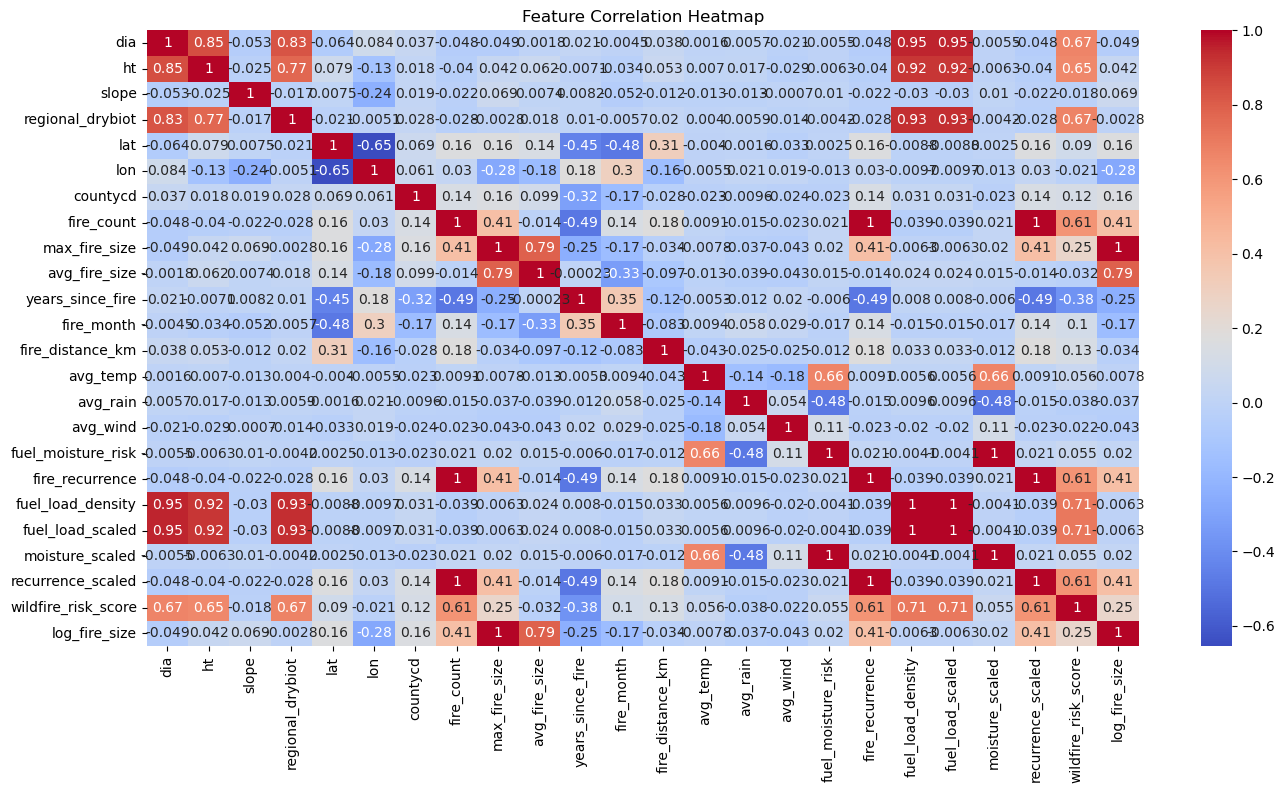

In [252]:
#Visualise the final ML table correlation with each other
corr = vegetation_risk_data.corr(method="spearman", numeric_only=True)

plt.figure(figsize=(16,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

Our feature selection for model training will be based on the Correlation analysis from the plot . Only strong relationships with the target, among derived fire and vegetation features will be retained for training. To avoid multicollinearity and data leakage, redundant variables will be  removed before modeling.